## 1. Instalação de Dependências

Instala o pacote `kagglehub`, utilizado para baixar datasets diretamente da plataforma Kaggle de forma programática.

In [1]:
!pip install -q kagglehub

## 2. Importação das Bibliotecas

Importa todas as bibliotecas necessárias para o projeto:
- **os, cv2, numpy, pandas**: manipulação de arquivos, imagens e dados
- **matplotlib, seaborn**: visualização de gráficos
- **PIL**: suporte a imagens truncadas
- **sklearn**: métricas de avaliação (relatório de classificação, matriz de confusão, curva ROC)
- **TensorFlow / Keras**: construção e treinamento do modelo de deep learning

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 3. Download do Dataset

Utiliza o `kagglehub` para fazer o download automático do dataset **Wildfire Prediction Dataset** do Kaggle. O caminho local onde o dataset foi salvo é armazenado na variável `path`.

In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "abdelghaniaaba/wildfire-prediction-dataset"
)

print(path)

100%|██████████| 1.45G/1.45G [00:22<00:00, 68.5MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1


## 4. Exploração da Estrutura de Diretórios

Percorre recursivamente os diretórios do dataset para visualizar como os arquivos estão organizados (pastas de treino, validação e teste, além das subpastas por classe).

In [4]:
for root, dirs, files in os.walk(path):
    print(root)

/root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1
/root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1/valid
/root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1/valid/wildfire
/root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1/valid/nowildfire
/root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1/test
/root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1/test/wildfire
/root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1/test/nowildfire
/root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1/train
/root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1/train/wildfire
/root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1/train/nowildfire


## 5. Contagem de Imagens por Classe

Lista as classes presentes na pasta de treino e exibe a quantidade de imagens em cada uma, permitindo verificar o balanceamento do dataset.

In [5]:
train_dir = os.path.join(path, "train")

classes = os.listdir(train_dir)

for classe in classes:
    qtd = len(os.listdir(os.path.join(train_dir, classe)))
    print(f"{classe}: {qtd}")

wildfire: 15750
nowildfire: 14500


## 6. Visualização de Amostras Aleatórias

Exibe 6 imagens selecionadas aleatoriamente do conjunto de treino, organizadas em grade 2x3, com o nome da classe como título. Útil para inspecionar visualmente a qualidade e diversidade das imagens.

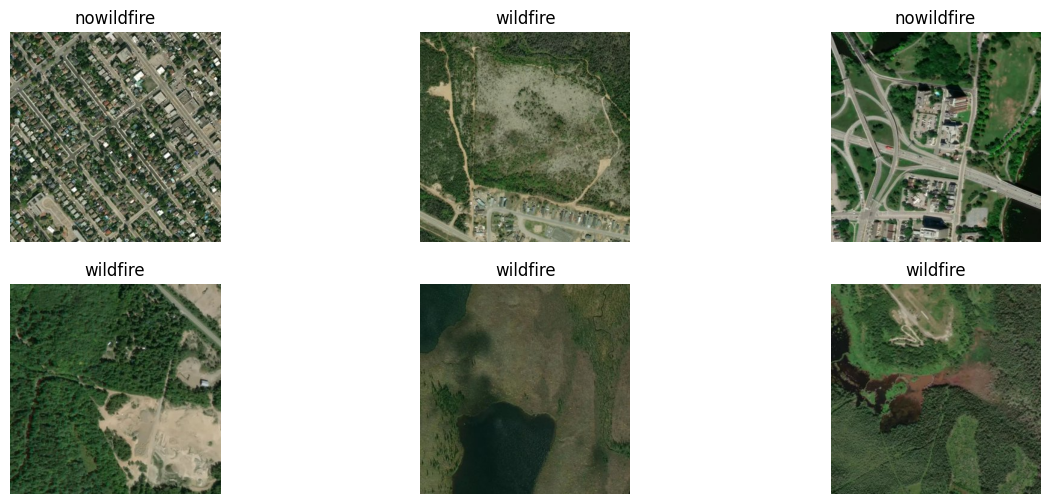

In [33]:
import random

plt.figure(figsize=(15,6))

for i in range(6):

    classe = random.choice(classes)

    img_name = random.choice(
        os.listdir(
            os.path.join(train_dir, classe)
        )
    )

    img_path = os.path.join(
        train_dir,
        classe,
        img_name
    )

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(classe)
    plt.axis("off")

plt.show()

## 7. Distribuição das Classes (Gráfico)

Gera um gráfico de barras com a distribuição de imagens por classe no conjunto de treino, facilitando a identificação de possível desbalanceamento entre as categorias.

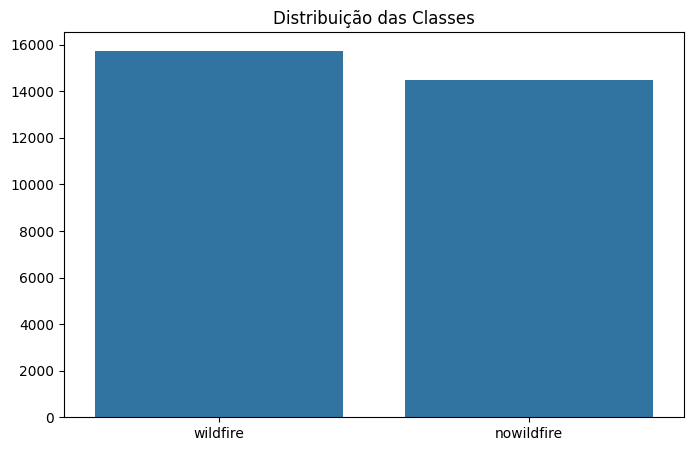

In [7]:
contagem = []

for classe in classes:

    qtd = len(
        os.listdir(
            os.path.join(train_dir, classe)
        )
    )

    contagem.append(qtd)

plt.figure(figsize=(8,5))

sns.barplot(
    x=classes,
    y=contagem
)

plt.title("Distribuição das Classes")
plt.show()

## 8. Configuração do Data Augmentation

Define os parâmetros de pré-processamento e augmentação de dados:
- **Treino**: aplica rotação, zoom, espelhamento horizontal/vertical e variação de brilho para aumentar a diversidade dos dados
- **Validação/Teste**: apenas normaliza os pixels para o intervalo [0, 1], sem augmentação

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8,1.2]
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

## 9. Criação dos Geradores de Dados

Cria três geradores de imagens (train, validação e teste) que carregam as imagens diretamente dos diretórios, redimensionando para 224×224 pixels e organizando em batches de 32. O `class_mode='binary'` indica classificação binária (wildfire vs. no wildfire).

In [12]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(path,"train"),
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(path,"valid"),
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(path,"test"),
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 30250 images belonging to 2 classes.
Found 6300 images belonging to 2 classes.
Found 6300 images belonging to 2 classes.


## 10. Carregamento do Modelo Base (EfficientNetB0)

Carrega a arquitetura **EfficientNetB0** pré-treinada no ImageNet com `include_top=False` (sem a camada de classificação original). As camadas do modelo base são congeladas (`trainable=False`) para aplicar Transfer Learning.

In [13]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 11. Construção da Cabeça de Classificação

Adiciona camadas customizadas sobre o modelo base:
- **GlobalAveragePooling2D**: reduz o mapa de features para um vetor
- **BatchNormalization**: normaliza as ativações para estabilizar o treinamento
- **Dropout(0.3)**: regularização para evitar overfitting
- **Dense(128, relu)**: camada densa com ativação ReLU
- **Dense(1, sigmoid)**: saída binária com probabilidade entre 0 e 1

In [14]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dropout(0.3)(x)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

## 12. Compilação e Resumo do Modelo

Compila o modelo com:
- **Otimizador Adam**: adaptativo e eficiente para deep learning
- **Loss binary_crossentropy**: função de perda adequada para classificação binária
- **Métrica accuracy**: acompanha a acurácia durante o treinamento

Exibe o resumo da arquitetura completa do modelo.

In [15]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 13. Configuração dos Callbacks

Define três callbacks para controlar o treinamento:
- **EarlyStopping**: interrompe o treino se a validação não melhorar por 5 épocas, restaurando os melhores pesos
- **ReduceLROnPlateau**: reduz a taxa de aprendizado em 80% se não houver melhora por 3 épocas
- **ModelCheckpoint**: salva automaticamente o melhor modelo em `best_model.keras`

In [16]:
early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    patience=3,
    factor=0.2
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    save_best_only=True
)

## 14. Treinamento do Modelo

Inicia o treinamento com os dados de treino e validação por até 5 épocas, utilizando os callbacks configurados. O histórico de métricas (acurácia e loss por época) é armazenado em `history` para análise posterior.

In [17]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 504s 500ms/step - accuracy: 0.6948 - loss: 0.5996 - val_accuracy: 0.8335 - val_loss: 0.4797 - learning_rate: 0.0010
Epoch 2/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 434s 458ms/step - accuracy: 0.7379 - loss: 0.5383 - val_accuracy: 0.8390 - val_loss: 0.4338 - learning_rate: 0.0010
Epoch 3/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 445s 470ms/step - accuracy: 0.7486 - loss: 0.5215 - val_accuracy: 0.8400 - val_loss: 0.4416 - learning_rate: 0.0010
Epoch 4/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 436s 461ms/step - accuracy: 0.7481 - loss: 0.5214 - val_accuracy: 0.8454 - val_loss: 0.4787 - learning_rate: 0.0010
Epoch 5/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 430s 454ms/step - accuracy: 0.7531 - loss: 0.5162 - val_accuracy: 0.8325 - val_loss: 0.4407 - learning_rate: 0.0010
Epoch 6/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 424s 448ms/step - accuracy: 0.7687 - loss: 0.4958 - val_accuracy: 0.8413 - val_loss: 0.4281 - learning_rate: 2.0000e-04
Epoch 7/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 432s 457ms/step - ac

## 15. Gráfico de Acurácia

Plota a evolução da acurácia ao longo das épocas tanto para o conjunto de treino quanto para a validação. Permite identificar overfitting (grande diferença entre as curvas) ou underfitting (ambas as curvas com valores baixos).

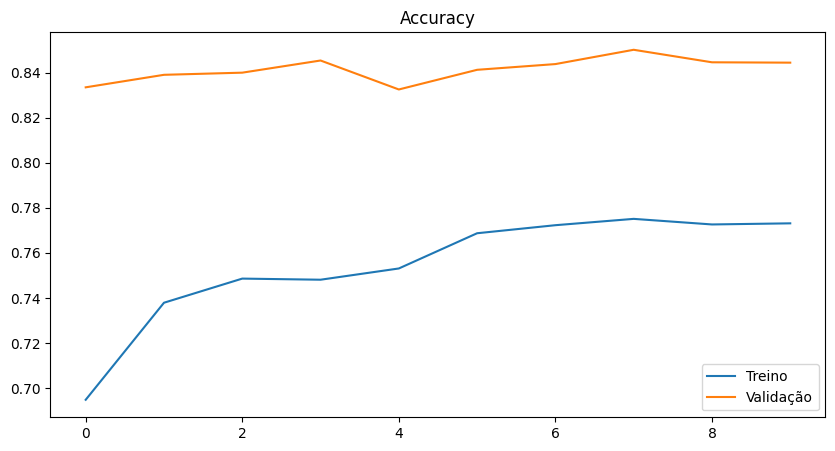

In [18]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Treino"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validação"
)

plt.legend()
plt.title("Accuracy")
plt.show()

## 16. Gráfico de Loss (Perda)

Plota a evolução da função de perda (binary crossentropy) durante o treinamento para treino e validação. Um loss de validação crescente enquanto o de treino cai indica overfitting.

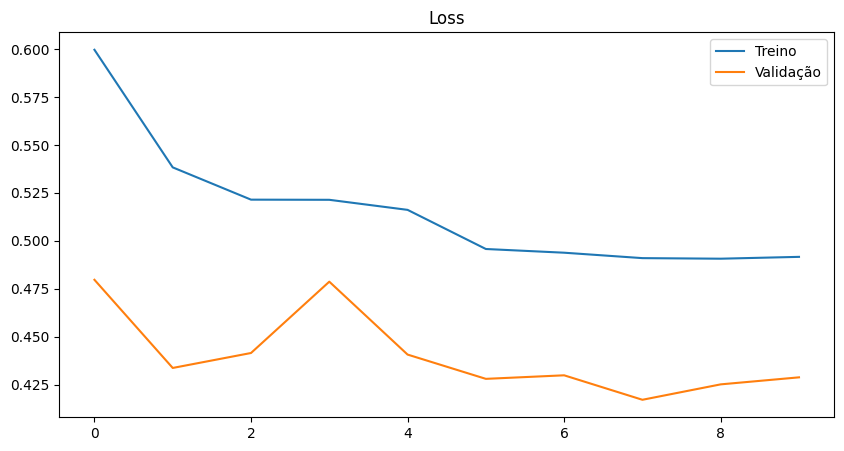

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Treino"
)

plt.plot(
    history.history["val_loss"],
    label="Validação"
)

plt.legend()
plt.title("Loss")
plt.show()

## 17. Avaliação no Conjunto de Teste

Avalia o desempenho final do modelo no conjunto de teste (dados nunca vistos durante o treinamento), exibindo a acurácia e o loss obtidos.

In [20]:
loss, acc = model.evaluate(
    test_generator
)

print("Accuracy:", acc)

197/197 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.8587 - loss: 0.4128
Accuracy: 0.858730137348175


## 18. Geração das Predições

Utiliza o modelo para prever as probabilidades de cada imagem do conjunto de teste. Em seguida, aplica limiar de 0.5 para converter as probabilidades em classes binárias (0 = no wildfire, 1 = wildfire).

In [21]:
pred_probs = model.predict(
    test_generator
)

preds = (
    pred_probs > 0.5
).astype(int)

197/197 ━━━━━━━━━━━━━━━━━━━━ 27s 104ms/step


## 19. Relatório de Classificação

Exibe métricas detalhadas por classe: **precision** (proporção de predições corretas), **recall** (proporção de positivos identificados) e **F1-score** (média harmônica de precision e recall). Essencial para avaliar o modelo além da simples acurácia.

In [22]:
print(classification_report(test_generator.classes, preds.flatten()))

              precision    recall  f1-score   support

           0       0.95      0.72      0.82      2820
           1       0.81      0.97      0.88      3480

    accuracy                           0.86      6300
   macro avg       0.88      0.85      0.85      6300
weighted avg       0.87      0.86      0.86      6300



## 20. Matriz de Confusão

Visualiza como o modelo acertou e errou as classificações:
- Diagonal principal: predições corretas
- Fora da diagonal: erros (falsos positivos e falsos negativos)

O heatmap facilita a identificação de quais classes o modelo confunde com mais frequência.

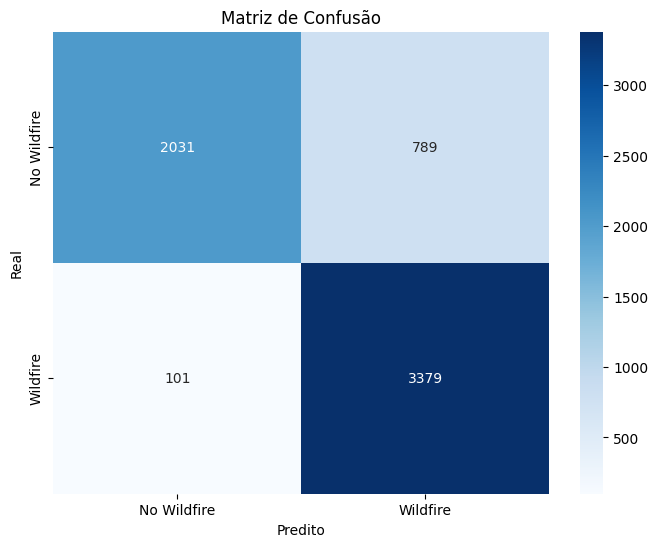

In [23]:
cm = confusion_matrix(
    test_generator.classes,
    preds
)

plt.figure(figsize=(8,6))

# Melhor assim
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Wildfire", "Wildfire"],
            yticklabels=["No Wildfire", "Wildfire"])
plt.xlabel("Predito")
plt.ylabel("Real")

plt.title("Matriz de Confusão")
plt.show()

## 21. Curva ROC e AUC

Traça a curva ROC (Receiver Operating Characteristic) comparando a taxa de verdadeiros positivos (TPR) com a taxa de falsos positivos (FPR). O valor **AUC** (Área sob a curva) sintetiza a capacidade discriminativa do modelo — quanto mais próximo de 1.0, melhor.

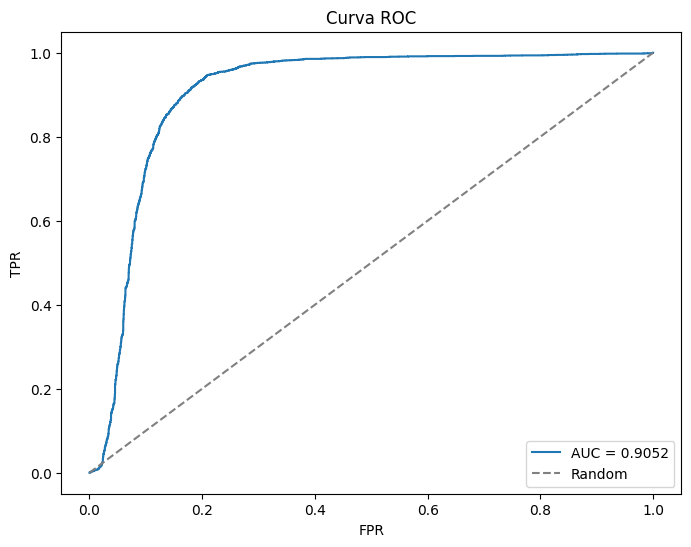

In [24]:
fpr, tpr, _ = roc_curve(test_generator.classes, pred_probs.flatten())

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Random")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

plt.title("Curva ROC")
plt.show()

## 22. Importação do Módulo de Imagem

Importa o submódulo `image` do Keras para carregar e pré-processar imagens individuais, necessário para a função de predição de novas imagens.

In [25]:
from tensorflow.keras.preprocessing import image

## 23. Função de Predição Individual

Define a função `predict_image(img_path)` que:
1. Carrega e redimensiona a imagem para 224×224
2. Normaliza os pixels para [0, 1]
3. Adiciona dimensão de batch
4. Executa a predição com o modelo treinado
5. Exibe a imagem com o resultado e a confiança da predição como título

In [26]:
def predict_image(img_path):

    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    prediction = model.predict(
        img_array
    )[0][0]

    plt.imshow(img)
    plt.axis("off")

    if prediction > 0.5:
        plt.title(
            f"Wildfire ({prediction:.2%})"
        )
    else:
        plt.title(
            f"No Wildfire ({1-prediction:.2%})"
        )

    plt.show()

## 24. Predição — Imagem 1

Aplica a função `predict_image` em uma imagem de satélite específica , exibindo a classificação do modelo e a porcentagem de confiança.

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step


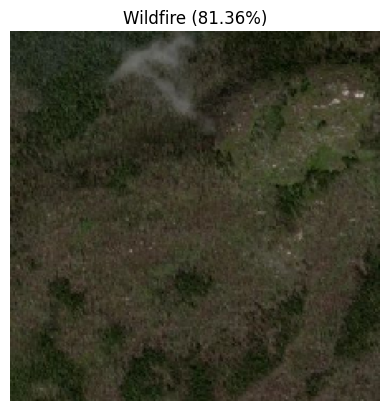

In [27]:
predict_image(
    "/content/-62.39074,51.35761.jpg"
)

## 25. Predição — Imagem 2

Aplica a função `predict_image` em uma segunda imagem de satélite para validar o comportamento do modelo em outro exemplo real.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


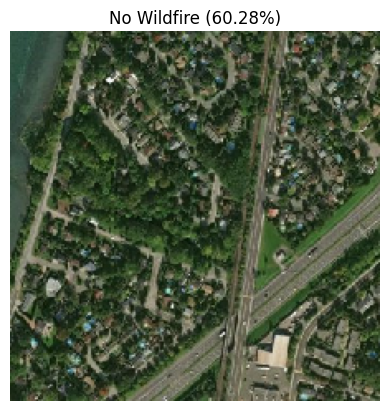

In [29]:
predict_image(
    "/content/-73.45599,45.598544.jpg"
)

# Aplicação no Mundo Real

O sistema pode ser integrado em:

- IBAMA
- Defesa Civil
- INPE
- Secretarias Ambientais

Funcionalidades:

- Monitoramento contínuo
- Alertas automáticos
- Identificação de áreas críticas
- Apoio à fiscalização
- Controle de queimadas
- Proteção de áreas de preservação

## Conclusão

Foi desenvolvido um modelo baseado em EfficientNetB0 capaz de identificar padrões associados à ocorrência de incêndios florestais em imagens de satélite.

O modelo demonstrou potencial para aplicação em sistemas de monitoramento ambiental, contribuindo para:

- Preservação
- Prevenção de queimadas
- Apoio à tomada de decisão
- Fiscalização de áreas protegidas

A utilização de Transfer Learning permitiu obter elevada capacidade de generalização com menor custo computacional.